## 1. Data Collection

For this project, the dataset was collected using the **TVMaze API**, which provides detailed information about TV shows.  
Data was gathered from all available pages (0–44), resulting in a comprehensive dataset containing thousands of shows.

During this process:
- A request was sent to each API page.
- All show-related fields such as ID, name, type, language, genres, runtime, premiere date, end date, rating, and summary were extracted.
- The collected records were stored in a list and then converted into a pandas DataFrame.

The raw dataset was saved locally as **`data_before_cleaning.csv`** and used for the inspection and cleaning steps that follow.


In [1]:
import requests
import pandas as pd
import time

shows = []

for page in range(0, 45):
    url = f"https://api.tvmaze.com/shows?page={page}"
    response = requests.get(url)
    time.sleep(0.5)  

    
    if response.status_code == 200:
        data = response.json()
        for show in data:
            shows.append({
                'id': show['id'],
                'name': show['name'],
                'type': show['type'],
                'language': show.get('language', 'Unknown'),
                'genres': ', '.join(show['genres']) if show['genres'] else '',
                'status': show['status'],
                'runtime': show.get('runtime', None),
                'premiered': show.get('premiered', None),
                'ended': show.get('ended', None),
                'rating_average': show['rating'].get('average', None) if show.get('rating') else None,
                'summary': show.get('summary', None)
            })
    else:
        print(f"Error on page {page}: {response.status_code}")
        break

# Create DataFrame
df = pd.DataFrame(shows)
print(f"Number of rows collected: {len(df)}")

df.to_csv("data_before_cleaning.csv", index=False, encoding='utf-8')
print("Raw data saved as 'data_before_cleaning.csv' in this notebook")

Number of rows collected: 10557
Raw data saved as 'data_before_cleaning.csv' in this notebook


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
import warnings
warnings.filterwarnings('ignore')

## 2. Dataset Overview

The dataset contains information about TV shows, including:
- **Categorical features:** name, type, language, genres, status  
- **Numerical features:** runtime, rating_average  
- **Date features:** premiered, ended  
- **Text field:** summary

The data is sourced from the TVMaze API, a public service with rate limits (e.g., 30 requests per minute) to prevent abuse. We respected these by adding small delays between requests and collecting in batches, ensuring ethical usage. The large size (~10k rows) may lead to imbalances, such as over-representation of English-language shows.

After loading the data, we inspected:
- The shape of the dataset (number of rows and columns)
- Data types for each column
- Unique values per feature
- Missing values per column
- Duplicate rows

This overview helped identify inconsistencies such as missing dates, missing genres, negative values, HTML text in summaries, and inconsistent date ranges (e.g., `ended < premiered`).

In [3]:
df = pd.read_csv("data_before_cleaning.csv")
df

,id,name,type,language,genres,status,runtime,premiered,ended,rating_average,summary
0,1,Under the Dome,Scripted,English,"Drama, Science-Fiction, Thriller",Ended,60.0,2013-06-24,2015-09-10,6.6,<p><b>Under the Dome</b> is the story of a sma...
1,2,Person of Interest,Scripted,English,"Action, Crime, Science-Fiction",Ended,60.0,2011-09-22,2016-06-21,8.8,<p>You are being watched. The government has a...
2,3,Bitten,Scripted,English,"Drama, Horror, Romance",Ended,60.0,2014-01-11,2016-04-15,7.4,<p>Based on the critically acclaimed series of...
3,4,Arrow,Scripted,English,"Drama, Action, Science-Fiction",Ended,60.0,2012-10-10,2020-01-28,7.4,"<p>After a violent shipwreck, billionaire play..."
4,5,True Detective,Scripted,English,"Drama, Crime, Thriller",Running,60.0,2014-01-12,NaN,8.1,<p>Touch darkness and darkness touches you bac...
...,...,...,...,...,...,...,...,...,...,...,...
10552,11242,Achter de Rug,Reality,Dutch,NaN,Ended,50.0,2015-04-21,2016-06-07,NaN,"<p>In <b>Achter de Rug</b>, two well-known peo..."
10553,11245,De Dag,Scripted,Dutch,"Drama, Action, Crime",Ended,45.0,2018-08-01,2018-08-01,7.1,<p>The nerve-racking events of a cold winter's...
10554,11247,Van Gils & gasten,Talk Show,Dutch,NaN,Ended,NaN,2015-08-31,2019-05-09,NaN,"<p><i><b>""Van Gils &amp; gasten""</b></i> is a ..."
10555,11248,Praise,Talk Show,English,NaN,Running,60.0,1997-05-27,NaN,NaN,"<p><b>Praise</b> (formally known as ""Praise th..."


In [4]:
print(df.shape)
df.info()

(10557, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10557 entries, 0 to 10556
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10557 non-null  int64  
 1   name            10557 non-null  object 
 2   type            10557 non-null  object 
 3   language        10556 non-null  object 
 4   genres          7967 non-null   object 
 5   status          10557 non-null  object 
 6   runtime         10092 non-null  float64
 7   premiered       10508 non-null  object 
 8   ended           9300 non-null   object 
 9   rating_average  3882 non-null   float64
 10  summary         10070 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 907.4+ KB


## 3. Data Inspection

During data inspection, several issues were identified:

### 🔹 Missing Values
- Missing values in `runtime`, `rating_average`, `genres`, `summary`
- Expected missing values in `ended` (many shows do not have an end date)
- Some missing `premiered` dates

### 🔹 Duplicates
- Duplicate rows detected and later removed.

### 🔹 Outliers
- Runtime outliers detected using IQR for each (genre, type) group which were removed during cleaning
- Some unusual negative or extremely high values.

### 🔹 Inaccurate or Inconsistent Entries
- Cases where `ended < premiered`, which are logically incorrect.
- HTML tags inside the `summary` column.

These issues guided the cleaning strategy applied in the next step.


In [5]:
for col in df.columns:
    print(f"column {col}:")
    print(f"Number of unique values: {len(df[col].value_counts())}")
    print(f"Number of missing values: {df[col].isnull().sum()}")
    print("-" *30)

duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

column id:
Number of unique values: 10557
Number of missing values: 0
------------------------------
column name:
Number of unique values: 10306
Number of missing values: 0
------------------------------
column type:
Number of unique values: 11
Number of missing values: 0
------------------------------
column language:
Number of unique values: 41
Number of missing values: 1
------------------------------
column genres:
Number of unique values: 655
Number of missing values: 2590
------------------------------
column status:
Number of unique values: 3
Number of missing values: 0
------------------------------
column runtime:
Number of unique values: 90
Number of missing values: 465
------------------------------
column premiered:
Number of unique values: 5318
Number of missing values: 49
------------------------------
column ended:
Number of unique values: 5430
Number of missing values: 1257
------------------------------
column rating_average:
Number of unique values: 70
Number of missi

In [6]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("numerical_features:", numerical_cols)
object_features = df.select_dtypes(include=['object']).columns.tolist()
print("object_features:", object_features)

numerical_features: ['id', 'runtime', 'rating_average']
object_features: ['name', 'type', 'language', 'genres', 'status', 'premiered', 'ended', 'summary']


In [7]:
categorical_features = ['type', 'language', 'genres', 'status']
print("categorical_features:", categorical_features)

categorical_features: ['type', 'language', 'genres', 'status']


In [8]:
df[numerical_cols].describe()

,id,runtime,rating_average
count,10557.000000,10092.000000,3882.000000
mean,5605.943639,48.938763,7.108861
std,3253.524074,26.690124,0.941378
min,1.000000,1.000000,1.000000
25%,2786.000000,30.000000,6.700000
50%,5591.000000,54.000000,7.300000
75%,8417.000000,60.000000,7.800000
max,11249.000000,360.000000,9.200000


In [9]:
for col in categorical_features:
 print(f"Column {col}:")
 print(df[col].value_counts())
 print("-"*30)

Column type:
type
Scripted       4804
Reality        1845
Documentary    1271
Animation      1205
Variety         386
Talk Show       341
Game Show       259
Sports          194
News            156
Award Show       52
Panel Show       44
Name: count, dtype: int64
------------------------------
Column language:
language
English            8369
Japanese            662
Dutch               249
Korean              237
Russian             198
Polish              161
German              127
Spanish             110
French               91
Chinese              43
Hungarian            42
Portuguese           34
Ukrainian            34
Swedish              28
Norwegian            27
Danish               23
Italian              20
Scottish Gaelic      18
Hindi                15
Turkish              11
Thai                 10
Hebrew                6
Czech                 5
Finnish               4
Tagalog               4
Irish                 3
Georgian              3
Bulgarian             3
Welsh  

In [10]:
def detect_outliers_per_genre_type(df, num_col):
    outliers_list = []
    bounds_info = {}
    
    for (genre, show_type), group_df in df.groupby(['genres', 'type']):
        if len(group_df) < 4:  # Skip small groups where IQR might not make sense
            continue
            
        Q1 = group_df[num_col].quantile(0.25)
        Q3 = group_df[num_col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR == 0:  # Avoid issues with zero IQR
            continue
            
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        group_key = (genre, show_type)
        bounds_info[group_key] = {'lower': lower, 'upper': upper}
        
        group_outliers = group_df[(group_df[num_col] < lower) | (group_df[num_col] > upper)]
        if not group_outliers.empty:
            group_outliers = group_outliers.copy()
            group_outliers['outlier_genre'] = genre
            group_outliers['outlier_type'] = show_type
            outliers_list.append(group_outliers)
    
    if outliers_list:
        all_outliers = pd.concat(outliers_list, ignore_index=True)
        return all_outliers, bounds_info
    else:
        return pd.DataFrame(), bounds_info


outliers_runtime_per_genre_type, bounds_per_genre_type = detect_outliers_per_genre_type(df, 'runtime')

print("Outliers in runtime per genre and type:")
if not outliers_runtime_per_genre_type.empty:
    display_cols = ['name', 'runtime', 'genres', 'type', 'outlier_genre', 'outlier_type']
    print(outliers_runtime_per_genre_type[display_cols])
    print(f"Total runtime outliers across all genre-type groups: {len(outliers_runtime_per_genre_type)}")
    
    # Count per genre-type group
    print("\nOutliers count per genre-type group:")
    outlier_counts = outliers_runtime_per_genre_type.groupby(['outlier_genre', 'outlier_type']).size()
    print(outlier_counts)
else:
    print("No outliers found per genre-type.")


Outliers in runtime per genre and type:
                          name  runtime             genres         type  \
0                  Major Lazer     10.0  Action, Adventure    Animation   
1           Fanboy & Chum Chum     11.0  Action, Adventure    Animation   
2                     Crossbow     30.0  Action, Adventure     Scripted   
3              Treasure Island     90.0  Action, Adventure     Scripted   
4                     Sea Hunt     30.0  Action, Adventure     Scripted   
..                         ...      ...                ...          ...   
265             The Secret War     50.0                War  Documentary   
266        Hell in the Pacific     50.0                War  Documentary   
267           Combat Countdown     46.0                War  Documentary   
268  Andy McNab's Tour of Duty     50.0                War  Documentary   
269      World War 1 in Colour     50.0                War  Documentary   

         outlier_genre outlier_type  
0    Action, Adventur

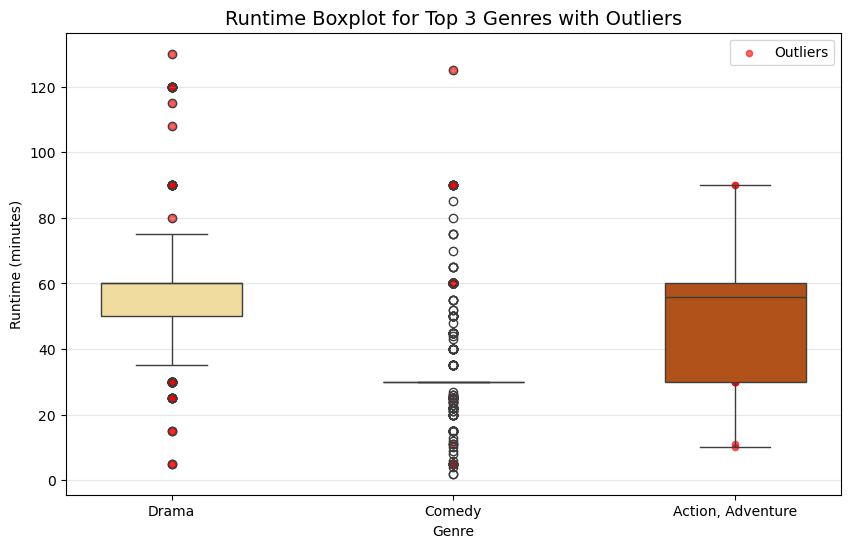

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

top_genres = outliers_runtime_per_genre_type['outlier_genre'].value_counts().head(3).index.tolist()
df_top = df[df['genres'].isin(top_genres)]

plt.figure(figsize=(10,6))

sns.boxplot(x='genres', y='runtime', data=df_top, palette='YlOrBr', width=0.5, showfliers=True)

if not outliers_runtime_per_genre_type.empty:
    for genre in top_genres:
        outliers_genre = outliers_runtime_per_genre_type[outliers_runtime_per_genre_type['outlier_genre']==genre]
        plt.scatter([genre]*len(outliers_genre), outliers_genre['runtime'],
                    color='red', s=20, alpha=0.6, label='Outliers' if genre==top_genres[0] else "")

plt.title("Runtime Boxplot for Top 3 Genres with Outliers", fontsize=14)
plt.ylabel("Runtime (minutes)")
plt.xlabel("Genre")
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()


In [13]:
# Inaccurate
print("=== Additional Issues ===")
df['premiered'] = pd.to_datetime(df['premiered'], errors='coerce')
df['ended'] = pd.to_datetime(df['ended'], errors='coerce')
date_issues = df[(df['ended'].notna()) & (df['premiered'].notna()) & (df['ended'] < df['premiered'])].shape[0]
print(f"Inaccurate Date Entries (ended < premiered): {date_issues}")


date_missing = df[df['premiered'].isna() | df['ended'].isna()]
print("Rows with missing dates:", len(date_missing))
print(date_missing[['name','premiered','ended']].head())

for col in ['runtime','rating_average']:
    if df[col].dtype == 'object':
        print(f"Column {col} has type object but should be numeric")

for col in categorical_features:
    empty_rows = df[df[col] == ""]
    print(f"Empty strings in {col}: {len(empty_rows)}")

# HTML count 
html_count = sum(df['summary'].apply(lambda x: bool(re.search(r'<.*?>', str(x))) if pd.notna(x) else False))
print(f"HTML in summary: {html_count}")

df[df['runtime'] < 0]
df[df['rating_average'] < 0] 

=== Additional Issues ===
Inaccurate Date Entries (ended < premiered): 6
Rows with missing dates: 1257
                     name  premiered ended
4          True Detective 2014-01-12   NaT
16       The Amazing Race 2001-09-05   NaT
28  American Horror Story 2011-10-05   NaT
30                  Fargo 2014-04-15   NaT
40              Outlander 2014-08-09   NaT
Empty strings in type: 0
Empty strings in language: 0
Empty strings in genres: 0
Empty strings in status: 0
HTML in summary: 10061


,id,name,type,language,genres,status,runtime,premiered,ended,rating_average,summary


## 4. Data Cleaning

A series of cleaning steps were applied to improve data quality:

### 🔹 Handling Missing Values
- Essential fields (`name`, `type`, `language`) → rows with missing values removed.
- `summary` → missing values replaced with "No summary".
- `runtime` → filled using the mode per show type.
- `genres` → filled using the mode of each (runtime, type) group.
- `rating_average` → filled using the median for each (genres, runtime) combination.

### 🔹 Fixing Date Issues
- Converted `premiered` and `ended` to datetime.
- Removed rows where `ended < premiered`.
- Assigned show status based on the presence of an end date.

### 🔹 Outlier Removal
- Runtime outliers detected per (genre, type) group using the IQR method.
- Outliers removed to ensure consistent analysis.

### 🔹 Text Cleaning
- HTML tags removed from the `summary` field.
- Extra spaces cleaned.

After applying all cleaning steps, the cleaned dataset was saved as **`tvshows_cleaned.csv`** and used for comparison and analysis.


In [14]:
#cleaning 
df = pd.read_csv("data_before_cleaning.csv")
df['premiered'] = pd.to_datetime(df['premiered'], errors='coerce')
df['ended'] = pd.to_datetime(df['ended'], errors='coerce')

df = df.dropna(subset=['name','language','type'])
print("After dropping rows with essential missing values:", df.shape)

df = df.drop(df[df['ended'] < df['premiered']].index)
print("After dropping rows where ended < premiered:", df.shape)

df['status'] = df.apply(
    lambda row: 'Ended' if pd.notna(row['ended']) 
                else row['status'] if pd.notna(row['status']) 
                else 'To Be Determined', axis=1
)
print("Status column cleaned!")


df = df.drop(df[(df['status'] == 'Ended') & (df['ended'].isna())].index)
print("Dropped inconsistent rows:", df.shape)

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates dropped. New shape: {df.shape}")
else:
    print("No duplicates to drop.")

After dropping rows with essential missing values: (10556, 11)
After dropping rows where ended < premiered: (10550, 11)
Status column cleaned!
Dropped inconsistent rows: (10504, 11)
No duplicates to drop.


In [15]:
outliers_runtime_per_genre_type, bounds_per_genre_type = detect_outliers_per_genre_type(df, 'runtime')

df_cleaned = df.drop(outliers_runtime_per_genre_type.index).reset_index(drop=True)

print("Outliers detected and removed:")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")
print(f"Number of rows removed: {len(outliers_runtime_per_genre_type)}")

print("\nRuntime summary after removing outliers:")
print(df_cleaned['runtime'].describe())
df = df_cleaned

Outliers detected and removed:
Cleaned DataFrame shape: (10233, 11)
Number of rows removed: 271

Runtime summary after removing outliers:
count    9790.000000
mean       48.887947
std        26.924468
min         1.000000
25%        30.000000
50%        50.000000
75%        60.000000
max       360.000000
Name: runtime, dtype: float64


In [16]:
df['summary'] = df['summary'].fillna('No summary')
df['summary'] = df['summary'].apply(lambda x: re.sub(r'<.*?>|&[a-zA-Z0-9#]+;', ' ', str(x)))
df['summary'] = df['summary'].str.replace(r'\s+', ' ', regex=True).str.strip()
df['summary'] = df['summary'].replace('', 'No summary')  # Ensure no empty after cleaning

print("Summary cleaned from HTML and extra spaces!")


Summary cleaned from HTML and extra spaces!


In [17]:
runtime_mode_per_type = df.groupby('type')['runtime'].agg(lambda x: x.mode()[0])

def fill_runtime_mode(row):
    if pd.isna(row['runtime']) :
        # Get the mode for the show type, otherwise use the global mode
        return runtime_mode_per_type.get(row['type'], df['runtime'].mode()[0])
    return row['runtime']
df['runtime'] = df.apply(fill_runtime_mode, axis=1)

print("Missing runtime values filled using mode per type.")
print("runtime summary after filling:")
print(df['runtime'].describe())

Missing runtime values filled using mode per type.
runtime summary after filling:
count    10233.000000
mean        49.169647
std         26.533981
min          1.000000
25%         30.000000
50%         60.000000
75%         60.000000
max        360.000000
Name: runtime, dtype: float64


In [18]:
genres_mode_per_runtime_type = df.groupby(['runtime', 'type'])['genres'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else pd.NA)

def fill_genres_mode(row):
    if pd.isna(row['genres']):
        # Get the mode for the specific runtime + type group, otherwise use global mode
        group_key = (row['runtime'], row['type'])
        mode_value = genres_mode_per_runtime_type.get(group_key, df['genres'].mode()[0])
        return mode_value if not pd.isna(mode_value) else df['genres'].mode()[0]  
    return row['genres']

df['genres'] = df.apply(fill_genres_mode, axis=1)

print("Missing genres values filled using mode per runtime and type.")

print("Genres value counts after filling:")
print(df['genres'].value_counts())


Missing genres values filled using mode per runtime and type.
Genres value counts after filling:
genres
Comedy                                    1862
Food                                      1130
Drama                                      504
Crime                                      464
Drama, Crime                               289
                                          ... 
Horror, Thriller                             1
Comedy, Action, Espionage                    1
Drama, Anime, Romance, Science-Fiction       1
Comedy, Adventure, Anime, Fantasy            1
Mystery, Supernatural                        1
Name: count, Length: 645, dtype: int64


In [19]:
rating_median_per_genre_runtime = df.groupby(['genres', 'runtime'])['rating_average'].median()

def fill_rating_median(row):
    if pd.isna(row['rating_average']):
        # Get the median for the specific genres + runtime group, otherwise use global median
        group_key = (row['genres'], row['runtime'])
        median_value = rating_median_per_genre_runtime.get(group_key)
        if pd.isna(median_value):
            # Fallback to global median if no group median
            return df['rating_average'].median()
        return median_value
    return row['rating_average']

df['rating_average'] = df.apply(fill_rating_median, axis=1)

print("Missing rating_average values filled using median per genre and runtime.")

df['rating_average'] = df['rating_average'].round(1) 
print("Rating_average summary after filling:")
print(df['rating_average'].describe())

Missing rating_average values filled using median per genre and runtime.
Rating_average summary after filling:
count    10233.000000
mean         7.053650
std          0.761186
min          1.000000
25%          6.700000
50%          7.300000
75%          7.500000
max          9.100000
Name: rating_average, dtype: float64


In [20]:
print("After cleaning:")
print("Shape:", df.shape)
print("Missing values:")
df.isnull().sum()

After cleaning:
Shape: (10233, 11)
Missing values:


id                   0
name                 0
type                 0
language             0
genres               0
status               0
runtime              0
premiered            3
ended             1181
rating_average       0
summary              0
dtype: int64

In [21]:
df.to_csv("tvshows_cleaned.csv", index=False, encoding="utf-8")
print("Cleaned data saved to 'tvshows_cleaned.csv'")

Cleaned data saved to 'tvshows_cleaned.csv'


## 5. Comparison: Before vs After Cleaning

A comparison was performed between the raw and cleaned datasets.

### 🔹 Rows
- Significant reduction in rows due to:
  - Removing inconsistent date entries
  - Dropping essential missing values
  - Removing runtime outliers

### 🔹 Missing Values
- Total missing values decreased substantially
- Numerical features no longer contain missing values
- Summary column has no missing values after replacement
- Expected missing values in date fields remain intentionally (e.g., ongoing shows)

### 🔹 Runtime & Rating Changes
- Runtime distribution became more consistent after removing outliers.
- `rating_average` became smoother after median-based filling.

### 🔹 Columns
- Number of columns remained the same, but the data inside is significantly cleaner.

Overall, the cleaned dataset is more consistent, accurate, and suitable for the EDA phase.


In [22]:

df_before = pd.read_csv("data_before_cleaning.csv")
df_after = pd.read_csv("tvshows_cleaned.csv")

print("=== Comparison Summary ===")
print(f"Rows Before Cleaning : {df_before.shape[0]}")
print(f"Rows After Cleaning  : {df_after.shape[0]}")
print(f"Rows Removed         : {df_before.shape[0] - df_after.shape[0]}")
print("-"*40)

print(f"Columns Before Cleaning : {df_before.shape[1]}")
print(f"Columns After Cleaning  : {df_after.shape[1]}")
print("-"*40)

missing_before = df_before.isnull().sum().sum()
missing_after = df_after.isnull().sum().sum()

print(f"Missing Values Before : {missing_before}")
print(f"Missing Values After  : {missing_after}")
print(f"Missing Values Fixed  : {missing_before - missing_after}")
print("-"*40)

missing_compare = pd.DataFrame({
    "Missing Before": df_before.isnull().sum(),
    "Missing After": df_after.isnull().sum()
})

print("=== Missing Values Per Column ===")
display(missing_compare)

print("\n=== Runtime Summary Before vs After ===")
print("Before:")
display(df_before['runtime'].describe())

print("After:")
display(df_after['runtime'].describe())

print("\n=== Rating Summary Before vs After ===")
print("Before:")
display(df_before['rating_average'].describe())

print("After:")
display(df_after['rating_average'].describe())


=== Comparison Summary ===
Rows Before Cleaning : 10557
Rows After Cleaning  : 10233
Rows Removed         : 324
----------------------------------------
Columns Before Cleaning : 11
Columns After Cleaning  : 11
----------------------------------------
Missing Values Before : 11524
Missing Values After  : 1184
Missing Values Fixed  : 10340
----------------------------------------
=== Missing Values Per Column ===


,Missing Before,Missing After
id,0,0
name,0,0
type,0,0
language,1,0
genres,2590,0
status,0,0
runtime,465,0
premiered,49,3
ended,1257,1181
rating_average,6675,0



=== Runtime Summary Before vs After ===
Before:


count    10092.000000
mean        48.938763
std         26.690124
min          1.000000
25%         30.000000
50%         54.000000
75%         60.000000
max        360.000000
Name: runtime, dtype: float64

After:


count    10233.000000
mean        49.169647
std         26.533981
min          1.000000
25%         30.000000
50%         60.000000
75%         60.000000
max        360.000000
Name: runtime, dtype: float64


=== Rating Summary Before vs After ===
Before:


count    3882.000000
mean        7.108861
std         0.941378
min         1.000000
25%         6.700000
50%         7.300000
75%         7.800000
max         9.200000
Name: rating_average, dtype: float64

After:


count    10233.000000
mean         7.053650
std          0.761186
min          1.000000
25%          6.700000
50%          7.300000
75%          7.500000
max          9.100000
Name: rating_average, dtype: float64

###  **Basic Summary of the Cleaned Dataset**

In this section, we provide a **preliminary summary** of the dataset after completing the cleaning process.  
This helps us understand the overall structure of the data and verify that the cleaning steps were effective.

This summary includes:

- The **shape of the dataset** (number of rows and columns).  
- The **data types** of all features.  
- **Descriptive statistics** for numeric columns such as `runtime` and `rating_average`.  
- The **top languages** in the dataset.  
- The distribution of **show types**.  
- An analysis of **genres** by splitting and counting all genre values across the dataset.


In [23]:
# Basic summary
df = pd.read_csv("tvshows_cleaned.csv")
print("Shape:", df.shape)
print("\nColumns and dtypes:")
print(df.dtypes)

# Numeric descriptive stats
print("\nNumeric summary:")
display(df[['runtime','rating_average']].describe())

# Categorical value counts (top 10)
print("\nTop languages:")
print(df['language'].value_counts().head(10))

print("\nTop types:")
print(df['type'].value_counts())

print("\nTop genres (note: genres are comma-separated):")


# split genres and count
from collections import Counter
genre_list = df['genres'].dropna().astype(str).str.split(',\s*').explode()
print(genre_list.value_counts().head(15))


Shape: (10233, 11)

Columns and dtypes:
id                  int64
name               object
type               object
language           object
genres             object
status             object
runtime           float64
premiered          object
ended              object
rating_average    float64
summary            object
dtype: object

Numeric summary:


,runtime,rating_average
count,10233.000000,10233.000000
mean,49.169647,7.053650
std,26.533981,0.761186
min,1.000000,1.000000
25%,30.000000,6.700000
50%,60.000000,7.300000
75%,60.000000,7.500000
max,360.000000,9.100000



Top languages:
language
English     8070
Japanese     658
Dutch        246
Korean       237
Russian      194
Polish       156
German       126
Spanish      110
French        90
Chinese       43
Name: count, dtype: int64

Top types:
type
Scripted       4556
Reality        1826
Documentary    1260
Animation      1182
Variety         377
Talk Show       333
Game Show       257
Sports          191
News            156
Award Show       52
Panel Show       43
Name: count, dtype: int64

Top genres (note: genres are comma-separated):
genres
Comedy             3413
Drama              3089
Action             1455
Crime              1406
Food               1213
Adventure          1006
Romance             678
Science-Fiction     646
Anime               566
Children            488
Family              457
Fantasy             441
Mystery             400
Music               382
History             365
Name: count, dtype: int64


# EDA Summary

- **Language × Type:** Count of shows per language and type.  
- **Language × Genre:** Count of shows per language and genre.  
- **Type × Genre:** Count of shows per type and genre.  
- **Number of Shows per Type:** How many shows exist for each type.  
- **Number of Shows per Year:** Shows premiered each year.  
- **Average Runtime per Genre:** Typical episode length by genre.  
- **Average Rating per Runtime:** Ratings vs episode length.  
- **Average Rating per Type:** Ratings by show type.  
- **Average Rating per Status:** Ratings for Running vs Ended shows.  
- **Average Rating per Genre:** Ratings by genre.


In [25]:
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("tvshows_cleaned.csv")

# Convert 'premiered' to datetime if not already
df['premiered'] = pd.to_datetime(df['premiered'], errors='coerce')

# Create 'premiered_year' column
df['premiered_year'] = df['premiered'].dt.year

# Genres split for analysis
df['genres_list'] = df['genres'].str.split(',\s*')

# Explode genres so each show appears once per genre for combinations
df_exploded = df.explode('genres_list')

#Language × Type
lang_type_counts = df.groupby(['language', 'type']).size().sort_values(ascending=False)
print("=== Language x Type counts ===")
print(lang_type_counts.head(20))

#Language × Genre
lang_genre_counts = df_exploded.groupby(['language', 'genres_list']).size().sort_values(ascending=False)
print("\n=== Language x Genre counts ===")
print(lang_genre_counts.head(20))

#Type × Genre
type_genre_counts = df_exploded.groupby(['type', 'genres_list']).size().sort_values(ascending=False)
print("\n=== Type x Genre counts ===")
print(type_genre_counts.head(20))

#Type × Number of Shows
type_counts = df['type'].value_counts()
print("\n=== Number of shows per Type ===")
print(type_counts)

#Premiered Year × Number of Shows
premiered_counts = df['premiered_year'].value_counts().sort_index()
print("\n=== Number of shows per Premiered Year ===")
print(premiered_counts.tail(25))

#Runtime × Genre (average runtime per genre)
runtime_genre_avg = df_exploded.groupby('genres_list')['runtime'].mean().sort_values(ascending=False)
print("\n=== Average runtime per Genre ===")
print(runtime_genre_avg.head(20))

#Runtime × Rating (average rating per runtime)
runtime_rating_avg = df.groupby('runtime')['rating_average'].mean().round(2).sort_values(ascending=False)
print("\n=== Average rating per Runtime ===")
print(runtime_rating_avg.head(20))

#Type × Rating (average rating per type)
type_rating_avg = df.groupby('type')['rating_average'].mean().round(2).sort_values(ascending=False)
print("\n=== Average rating per Type ===")
print(type_rating_avg)

#Status × Rating
status_rating_avg = df.groupby('status')['rating_average'].mean().round(2).sort_values(ascending=False)
print("\n=== Average rating per Status ===")
print(status_rating_avg)

#Genre × Rating (average rating per genre)
genre_rating_avg = df_exploded.groupby('genres_list')['rating_average'].mean().round(2).sort_values(ascending=False)
print("\n=== Average rating per Genre ===")
print(genre_rating_avg.head(20))


=== Language x Type counts ===
language  type       
English   Scripted       3332
          Reality        1693
          Documentary    1208
          Animation       594
Japanese  Animation       560
English   Variety         321
          Talk Show       291
Korean    Scripted        211
English   Game Show       210
          Sports          185
          News            145
Polish    Scripted        143
Russian   Scripted        142
Dutch     Scripted        134
German    Scripted        117
Japanese  Scripted         96
Spanish   Scripted         82
French    Scripted         71
English   Award Show       50
Dutch     Reality          44
dtype: int64

=== Language x Genre counts ===
language  genres_list    
English   Comedy             2622
          Drama              2099
          Food               1150
          Crime              1103
          Action             1024
          Adventure           781
Japanese  Anime               549
English   Science-Fiction     487
   

# **Visualizations Summary**


## 1. Pie Charts: Distribution of Categorical Features
- **Description:** Four separate pie charts visualizing categorical features (e.g., type, language, status, genres).  
- **Purpose:** To see proportions of different categories in the dataset.

## 2. Histogram: Rating Distribution
- **Description:** Histogram of TV show ratings.  
- **Purpose:** To understand the distribution of ratings (e.g., skewed, normal)

## 3. Line Plot: Number of Shows Over Years
- **Description:** Trend of how many shows premiered each year.  
- **Purpose:** To see changes in show production over time.

## 4. Bar Chart: Number of Shows by Type
- **Description:** Counts of shows for each type.  
- **Purpose:** To identify which show types are most common.

## 5. Bar Chart: Average Rating by Show Type
- **Description:** Average rating for individual shows (could highlight top-rated shows).  
- **Purpose:** To identify the best-rated shows.

## 6. Bar Chart: Status vs Rating
- **Description:** Shows average ratings for shows grouped by status (e.g., running, ended).  
- **Purpose:** To see if ongoing or ended shows tend to have different ratings.

## 7. Bar Chart: Runtime by Genres
- **Description:** Shows average runtime for each genre.  
- **Purpose:** To compare which genre generally have higher or lower runtime.

## 8. Scatter Plot: Runtime vs Rating
- **Description:** Each point represents a show, showing its runtime and rating.  
- **Purpose:** To see if longer or shorter shows tend to have higher ratin

## 9. Heatmap: Number of Shows by Type and Language
- **Description:** Heatmap showing the count of shows for each type-language combination.  
- **Purpose:** To easily spot which type-language combinations are most common.

## 10. Stacked Bar Chart: Number of Shows by Type and Genre
- **Description:** Each bar represents a show type, stacked by genres.  
- **Purpose:** To compare the distribution of genres within each show type.

## 11. Donut Chart: Average Rating by Top Genres
- **Description:** Donut chart visualizing the average ratings of the top genres.  
- **Purpose:** To quickly see which genres tend to have higher ratings in a visually appealing way.

## 12. Bar Chart: Average Duration per TV Show Type
- **Description:** Bar chart showing the average duration (in years) of shows for each type.  
- **Purpose:** To understand which types of shows run longer on average.

## 13. Bar Chart: Number of TV Shows by Duration Groups
- **Description:** Groups shows into duration ranges (e.g., 0–2 yrs, 2–5 yrs, 5–10 yrs...) and shows the count in each group.  
- **Purpose:** To see the most common show duration ranges and compare their frequencies.

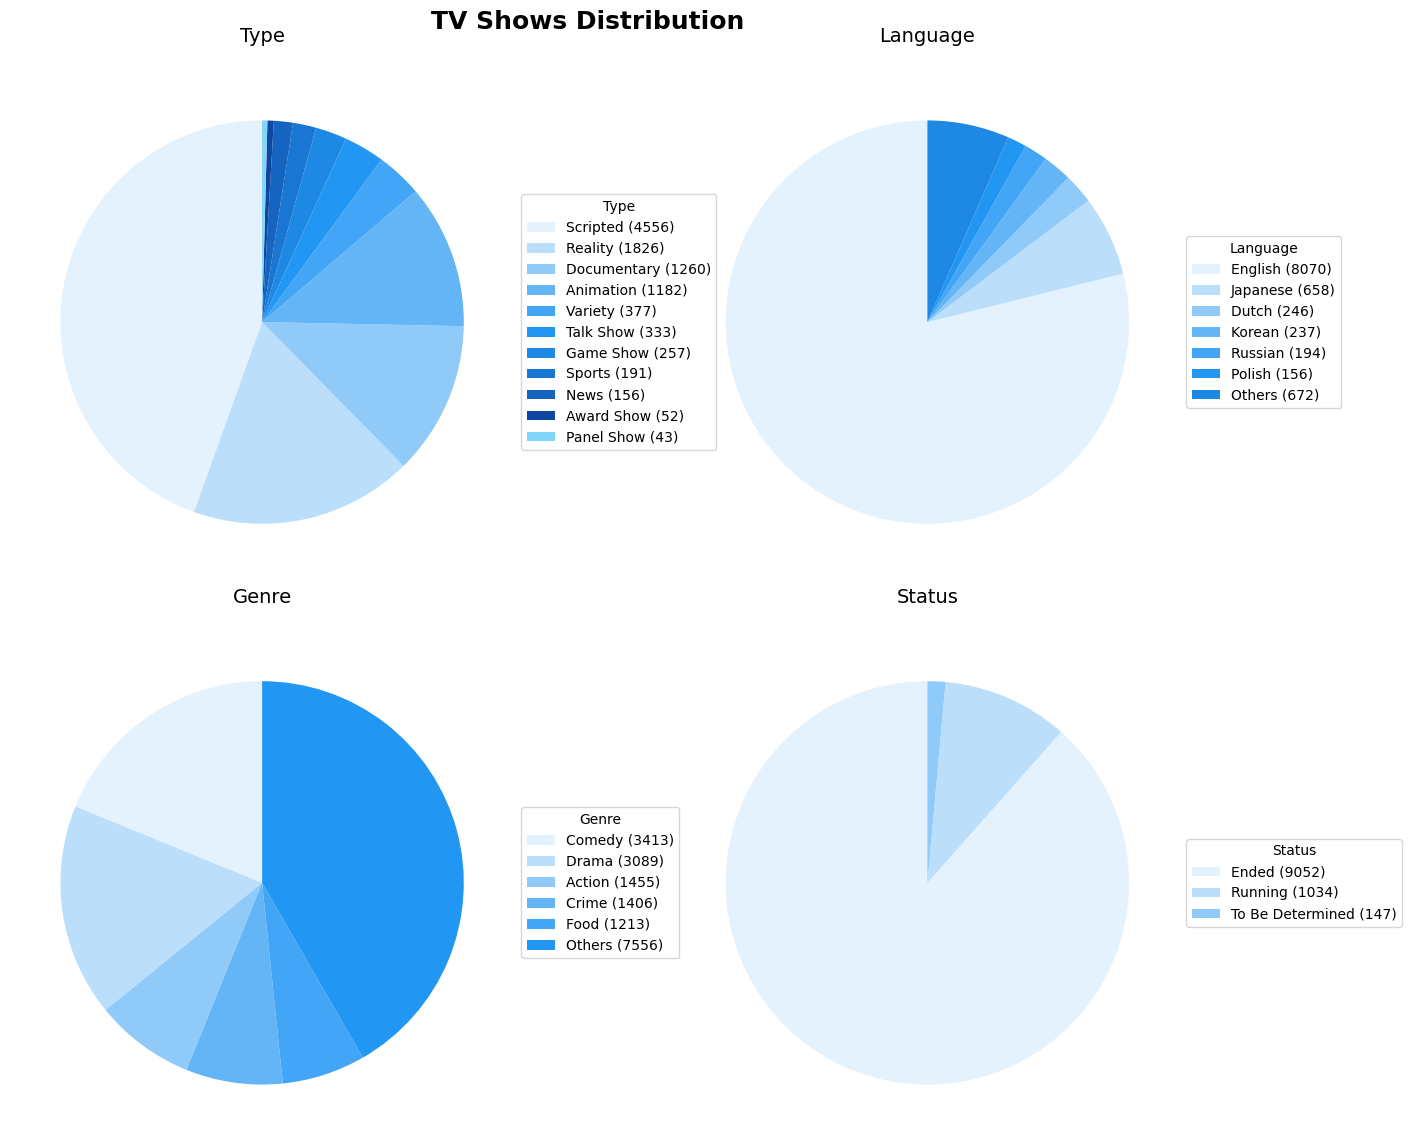

In [26]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("tvshows_cleaned.csv")
df['genres_list'] = df['genres'].str.split(',\s*')
df_exploded = df.explode('genres_list')

# Blue shades
blue_shades = ['#E3F2FD', '#BBDEFB', '#90CAF9', '#64B5F6', '#42A5F5', '#2196F3', 
               '#1E88E5', '#1976D2', '#1565C0', '#0D47A1', '#81D4FA', '#4FC3F7', 
               '#29B6F6', '#03A9F4', '#0277BD']

# Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('TV Shows Distribution', fontsize=18, fontweight='bold', y=0.95, x=0.4)

# 1. Type
type_counts = df['type'].value_counts()
wedges1, texts1 = axes[0, 0].pie(type_counts.values, colors=blue_shades[:len(type_counts)], startangle=90)
axes[0, 0].set_title('Type', fontsize=14, pad=20)
axes[0, 0].legend(wedges1, [f'{label} ({count})' for label, count in zip(type_counts.index, type_counts.values)],
                  title="Type", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# 2. Language - Top 6 + Others
lang_counts = df['language'].value_counts()
top6 = lang_counts.head(6)
others_count = lang_counts[6:].sum()
lang_labels = list(top6.index) + ['Others']
lang_values = list(top6.values) + [others_count]

wedges2, _ = axes[0, 1].pie(lang_values, colors=blue_shades[:7], startangle=90)
axes[0, 1].set_title('Language', fontsize=14, pad=20)
axes[0, 1].legend(wedges2, [f'{label} ({count})' for label, count in zip(lang_labels, lang_values)],
                  title="Language", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# 3. Genre - Top 5 + Others
genre_counts = df_exploded['genres_list'].value_counts()
top5 = genre_counts.head(5)
others_genre = genre_counts[5:].sum()
genre_labels = list(top5.index) + ['Others']
genre_values = list(top5.values) + [others_genre]

wedges3, _ = axes[1, 0].pie(genre_values, colors=blue_shades[:6], startangle=90)
axes[1, 0].set_title('Genre', fontsize=14, pad=20)
axes[1, 0].legend(wedges3, [f'{label} ({count})' for label, count in zip(genre_labels, genre_values)],
                  title="Genre", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# 4. Status
status_counts = df['status'].value_counts()
status_order = ['Ended', 'Running', 'To Be Determined']
status_values = [status_counts.get(s, 0) for s in status_order]

wedges4, _ = axes[1, 1].pie(status_values, colors=blue_shades[:3], startangle=90)
axes[1, 1].set_title('Status', fontsize=14, pad=20)
axes[1, 1].legend(wedges4, [f'{label} ({count})' for label, count in zip(status_order, status_values)],
                  title="Status", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))


plt.tight_layout()
plt.subplots_adjust(top=0.9, right=0.8)  
plt.show()

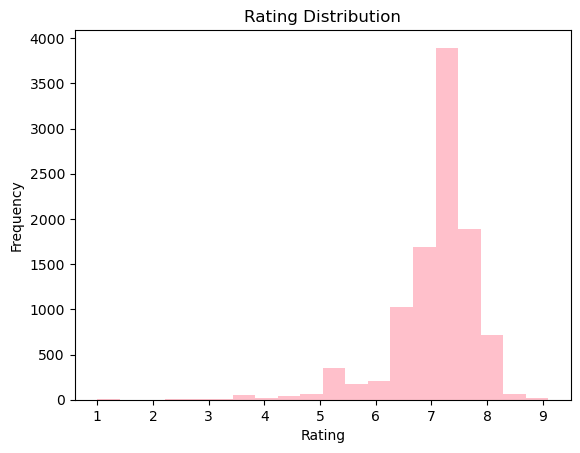

In [27]:
# Distribution of Ratings
plt.hist(df['rating_average'], bins=20, color='pink')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

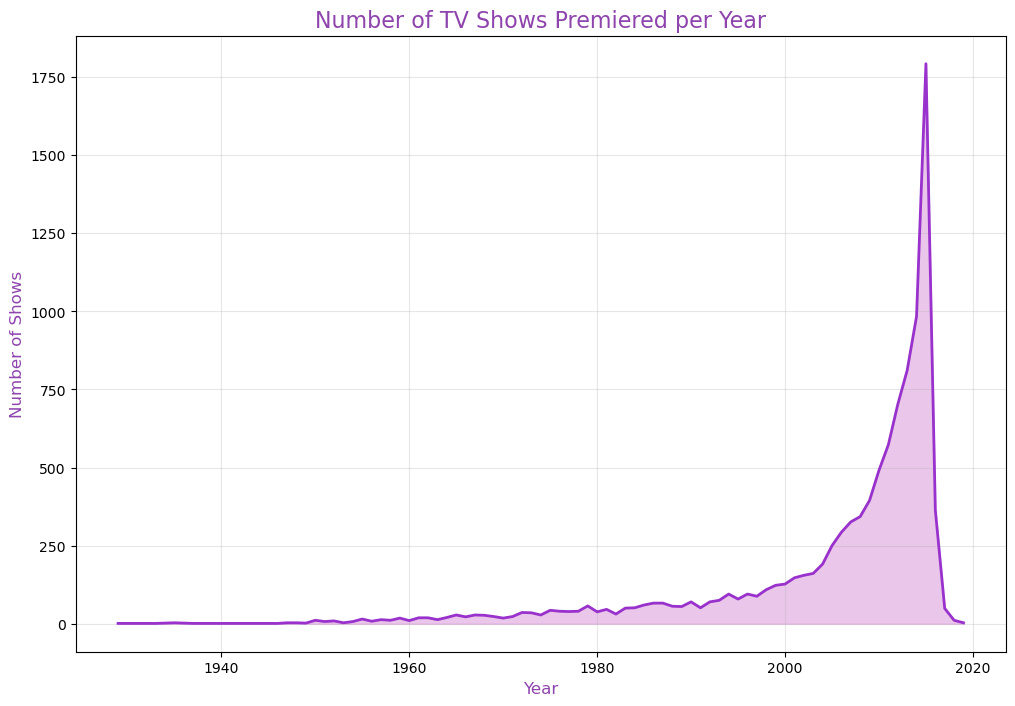

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("tvshows_cleaned.csv")
df['premiered'] = pd.to_datetime(df['premiered'], errors='coerce')
df['premiered_year'] = df['premiered'].dt.year

shows_per_year = df.groupby('premiered_year').size()

plt.figure(figsize=(12,8))

plt.fill_between(shows_per_year.index, shows_per_year.values, color='plum', alpha=0.6)

plt.plot(shows_per_year.index, shows_per_year.values, color='darkorchid', linewidth=2)
plt.title("Number of TV Shows Premiered per Year", fontsize=16, color="#8E44AD")
plt.xlabel("Year", fontsize=12 ,color="#8E44AD")
plt.ylabel("Number of Shows", fontsize=12, color="#8E44AD")
plt.grid(alpha=0.3)
plt.show()

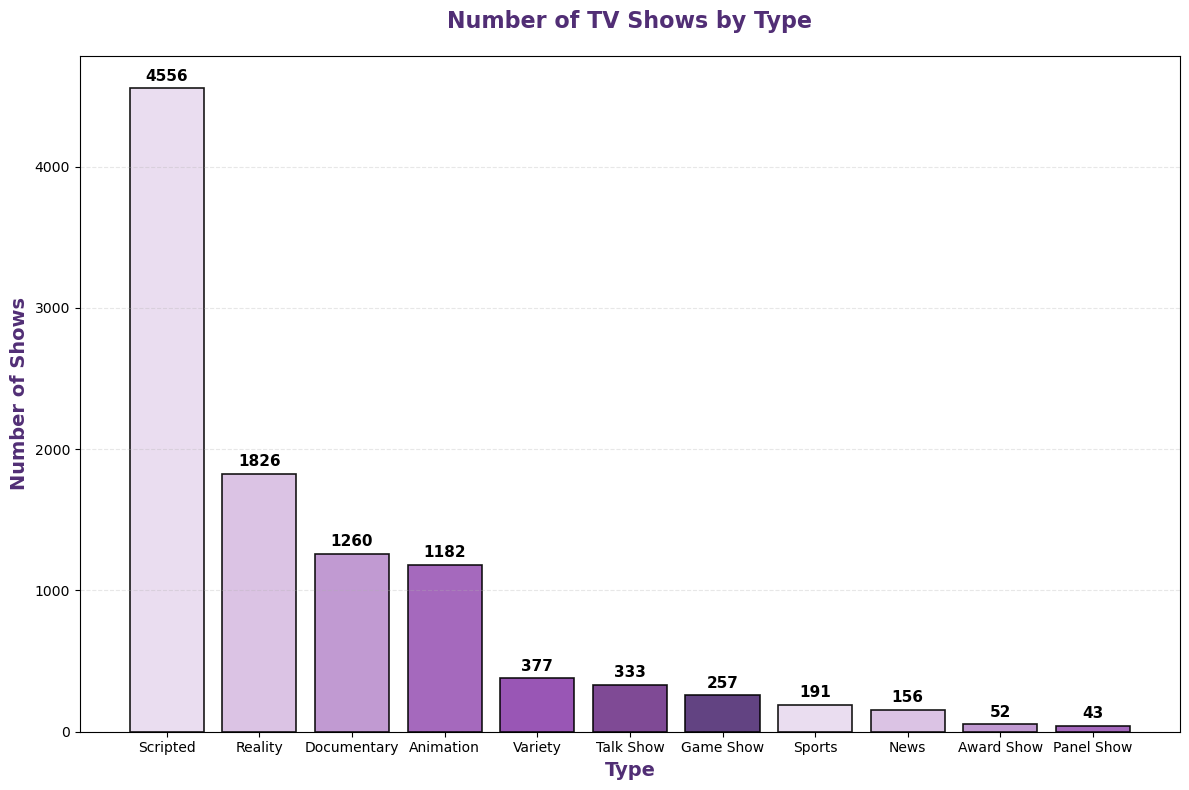

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("tvshows_cleaned.csv")


type_counts = df['type'].value_counts()


purple_shades = ['#E8DAEF', '#D7BDE2', '#BB8FCE', '#9B59B6', '#8E44AD', '#71368A', '#512E75']

plt.figure(figsize=(12, 8))
bars = plt.bar(type_counts.index, type_counts.values, 
               color=purple_shades[:len(type_counts)], 
               edgecolor='black', linewidth=1.2, alpha=0.9)


plt.title('Number of TV Shows by Type', fontsize=16, fontweight='bold', pad=20, color='#512E75')
plt.xlabel('Type', fontsize=14, fontweight='bold', color='#512E75')
plt.ylabel('Number of Shows', fontsize=14, fontweight='bold', color='#512E75')


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 30,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

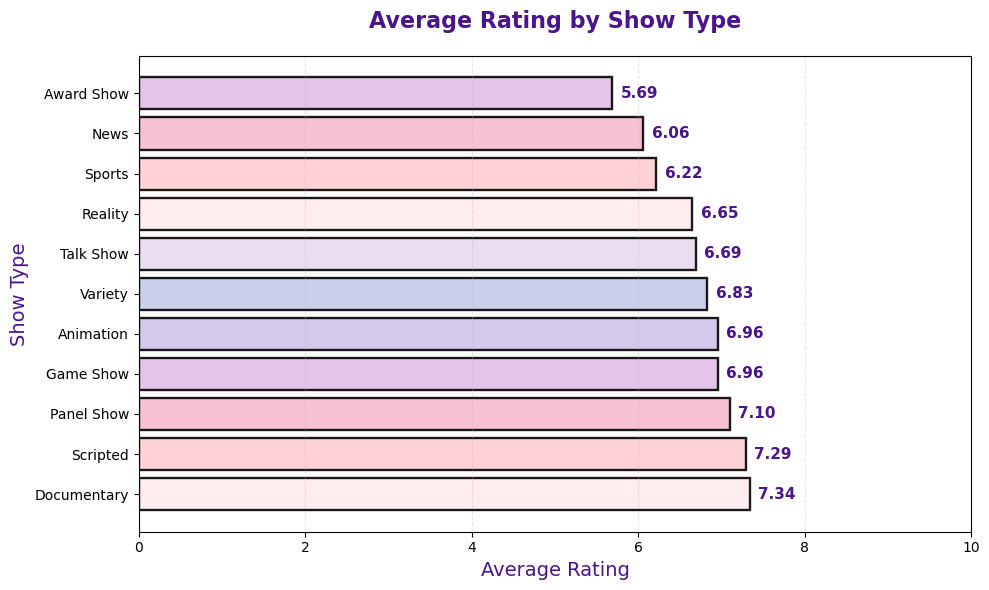

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("tvshows_cleaned.csv")

type_rating_avg = df.groupby('type')['rating_average'].mean().round(2).sort_values(ascending=False)

candy_colors = ['#FFEBEE', '#FFCDD2', '#F8BBD0', '#E1BEE7', '#D1C4E9', '#C5CAE9', '#E8DAEF']

plt.figure(figsize=(10, 6))
bars = plt.barh(type_rating_avg.index, type_rating_avg.values,
                color=candy_colors[:len(type_rating_avg)],
                edgecolor='black', linewidth=1.7, alpha=0.9)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', fontsize=11, fontweight='bold', color="#4A148C")

plt.title('Average Rating by Show Type', fontsize=16, fontweight='bold', pad=20, color='#4A148C')
plt.xlabel('Average Rating', fontsize=14, color='#4A148C')
plt.ylabel('Show Type', fontsize=14, color='#4A148C')

plt.xlim(0, 10)
plt.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


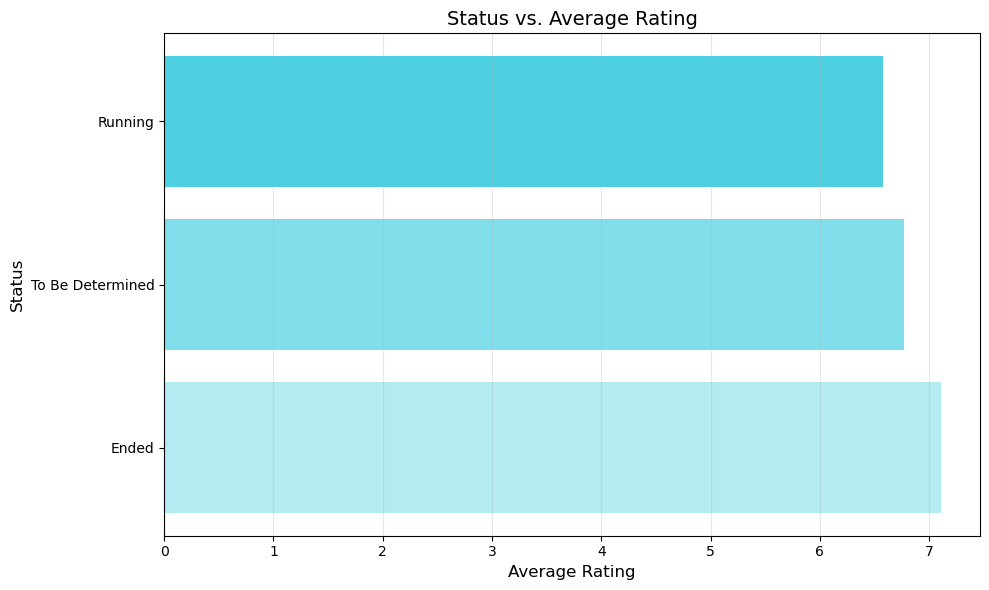

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("tvshows_cleaned.csv")

status_rating_avg = df.groupby('status')['rating_average'].mean().round(2).sort_values(ascending=False)

plt.figure(figsize=(10, 6))   
colors = ['#B2EBF2', '#80DEEA', '#4DD0E1']  
plt.barh(status_rating_avg.index, status_rating_avg.values, color=colors[:len(status_rating_avg)])    
plt.title('Status vs. Average Rating', fontsize=14)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Status', fontsize=12)
plt.grid(axis='x', alpha=0.3)  
plt.tight_layout()
plt.show()


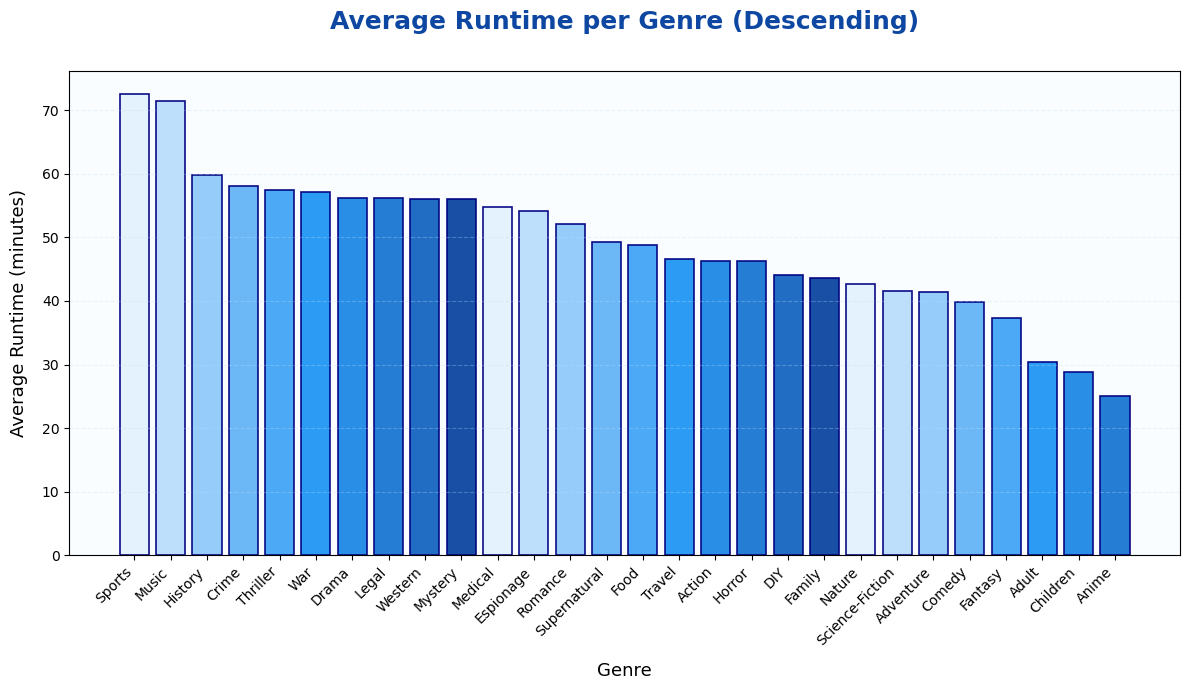

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("tvshows_cleaned.csv")

# Split genres
df['genres_list'] = df['genres'].str.split(',\s*')
df_exploded = df.explode('genres_list')

# Compute average runtime per genre (Descending)
runtime_per_genre = (
    df_exploded.groupby('genres_list')['runtime']
    .mean()
    .sort_values(ascending=False)
)

# Blue shades
blue_shades = ['#E3F2FD', '#BBDEFB', '#90CAF9', '#64B5F6', '#42A5F5', '#2196F3', 
               '#1E88E5', '#1976D2', '#1565C0', '#0D47A1']

plt.figure(figsize=(12, 7))

bars = plt.bar(runtime_per_genre.index, runtime_per_genre.values,
               color=blue_shades[:len(runtime_per_genre)],
               edgecolor='navy', linewidth=1.2, alpha=0.95)

plt.title('Average Runtime per Genre (Descending)', fontsize=18, fontweight='bold', pad=30, color='#0D47A1')
plt.xlabel('Genre', fontsize=13, labelpad=10)
plt.ylabel('Average Runtime (minutes)', fontsize=13, labelpad=10)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--', color='#BBDEFB')
plt.gca().set_facecolor('#FAFDFF')

plt.tight_layout()
plt.show()


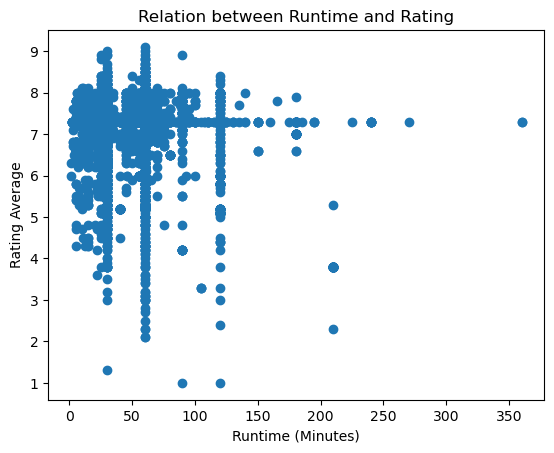

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the cleaned data
df = pd.read_csv("tvshows_cleaned.csv")

# Scatter plot for relation between Runtime and Rating
plt.figure()
plt.scatter(df['runtime'].dropna(), df['rating_average'].dropna())
plt.xlabel('Runtime (Minutes)')
plt.ylabel('Rating Average')
plt.title('Relation between Runtime and Rating')
plt.show()

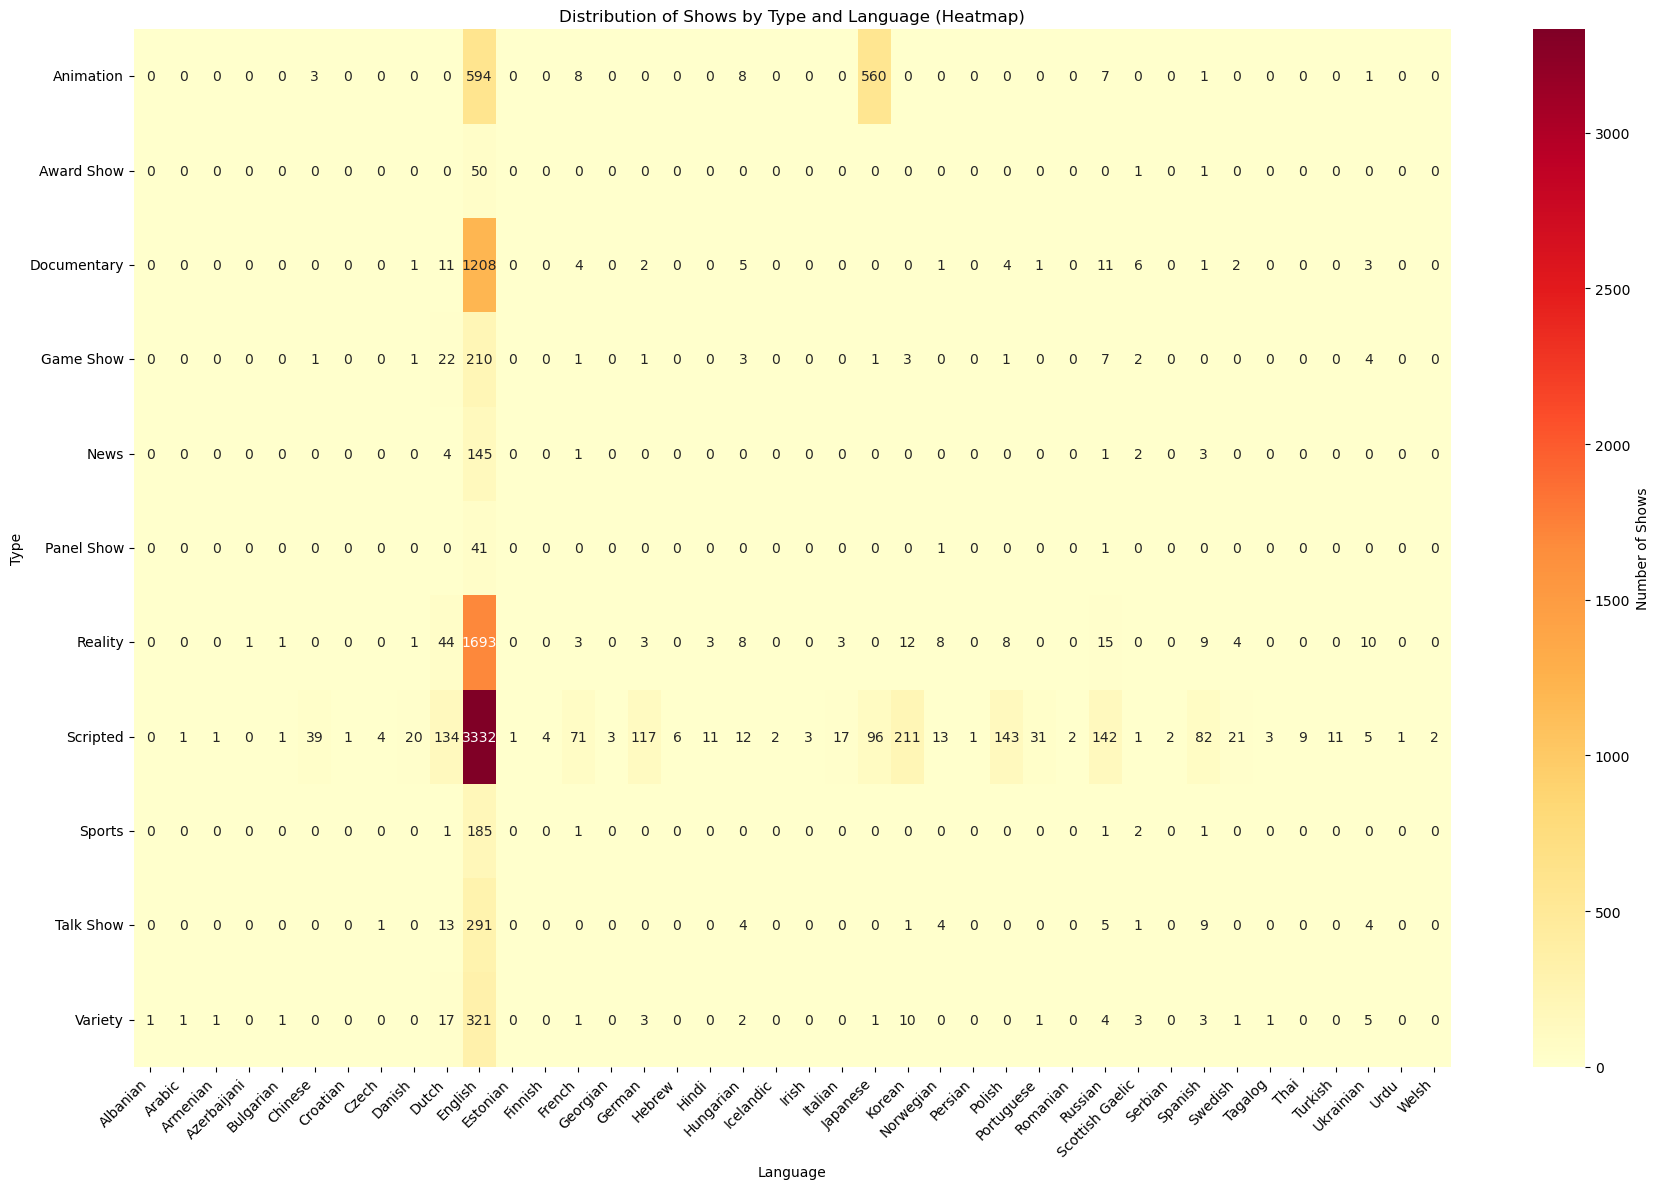

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned data
df = pd.read_csv("tvshows_cleaned.csv")

# Pivot table: rows = type, columns = language, values = count of shows
pivot = df.pivot_table(index='type', columns='language', values='id', aggfunc='count', fill_value=0)

# Heatmap visualization
plt.figure(figsize=(18, 12))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Number of Shows'})
plt.title('Distribution of Shows by Type and Language (Heatmap)')
plt.xlabel('Language')
plt.ylabel('Type')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


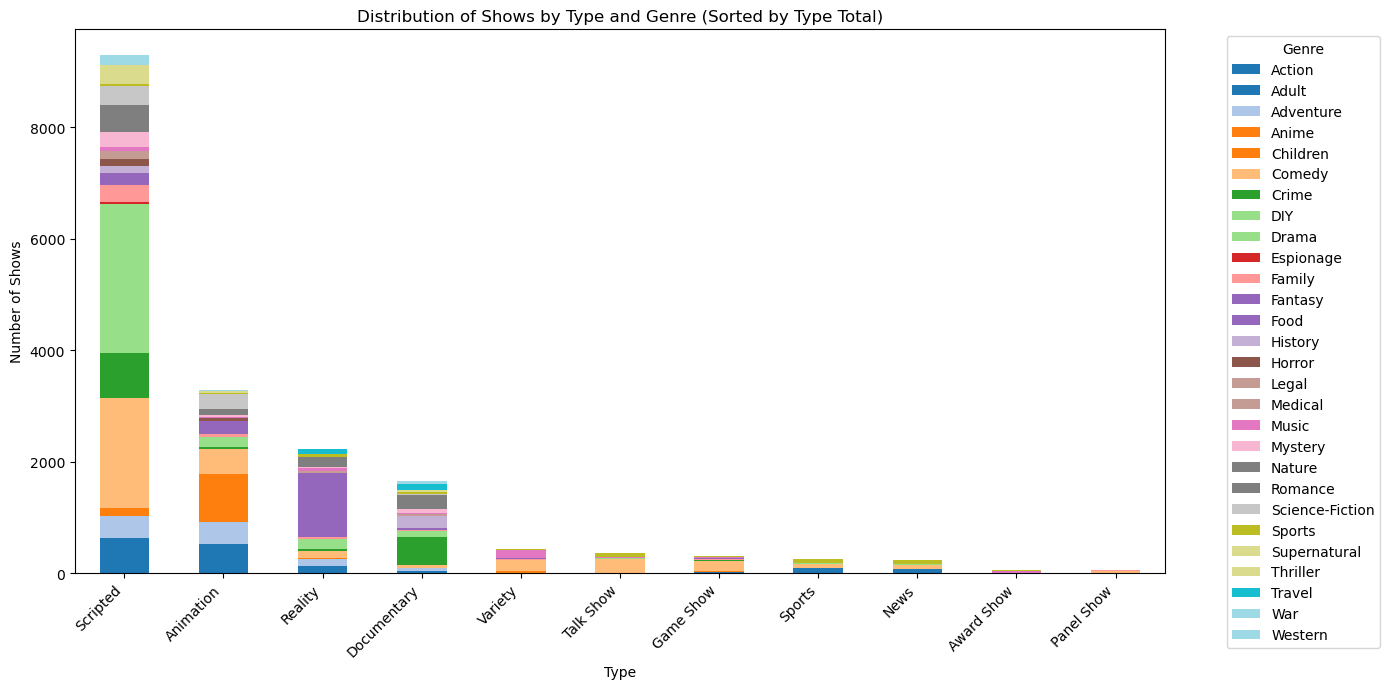

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned data
df = pd.read_csv("tvshows_cleaned.csv")

# Ensure genres are split into a list
df['genres_list'] = df['genres'].str.split(', ')

# Explode genres so each show-genre gets its own row
df_exploded = df.explode('genres_list')

# Create crosstab: rows = type, columns = genres, values = count
crosstab = pd.crosstab(df_exploded['type'], df_exploded['genres_list'])

# Sort by total count per type (descending)
crosstab = crosstab.loc[crosstab.sum(axis=1).sort_values(ascending=False).index]

# Stacked bar plot for Type and Genre Distribution
crosstab.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20')
plt.title('Distribution of Shows by Type and Genre (Sorted by Type Total)')
plt.xlabel('Type')
plt.ylabel('Number of Shows')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


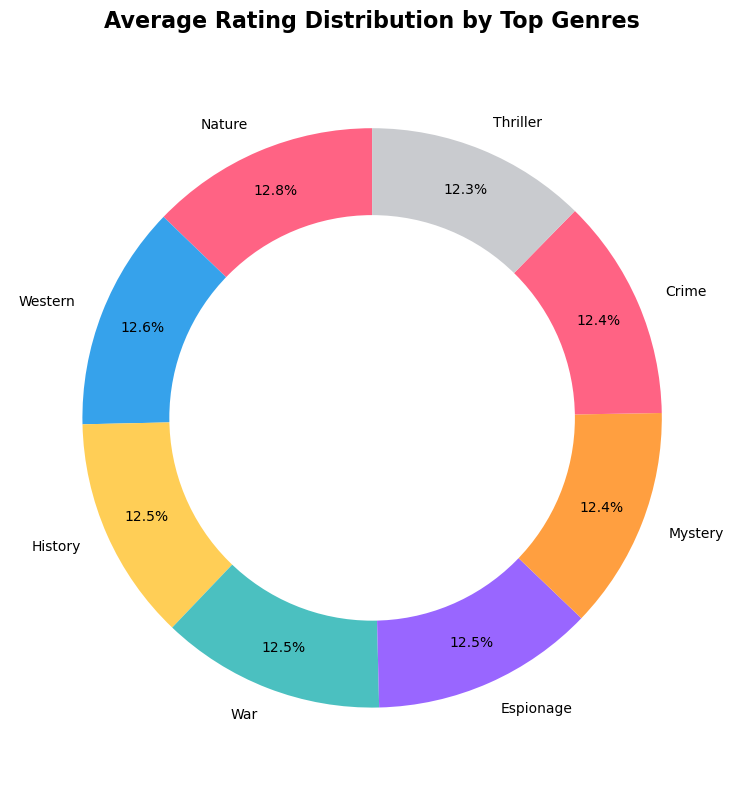

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("tvshows_cleaned.csv")
df['genres_list'] = df['genres'].str.split(',\s*')
df_exploded = df.explode('genres_list')

genre_rating_avg = df_exploded.groupby('genres_list')['rating_average'].mean().round(2).sort_values(ascending=False).head(8)

plt.figure(figsize=(8, 8))
colors = ['#FF6384', '#36A2EB', '#FFCE56', '#4BC0C0', '#9966FF', '#FF9F40', '#FF6384', '#C9CBCF']
wedges, texts, autotexts = plt.pie(genre_rating_avg.values, labels=genre_rating_avg.index, autopct='%1.1f%%',
                                   colors=colors[:len(genre_rating_avg)], startangle=90, pctdistance=0.85)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Average Rating Distribution by Top Genres', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

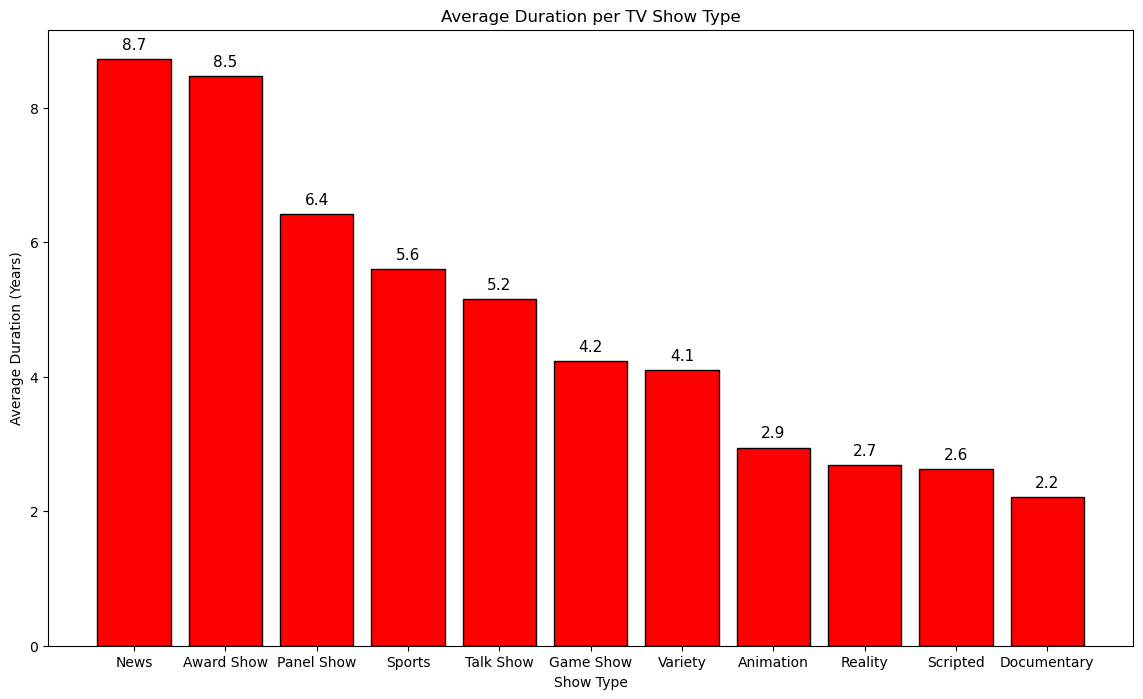

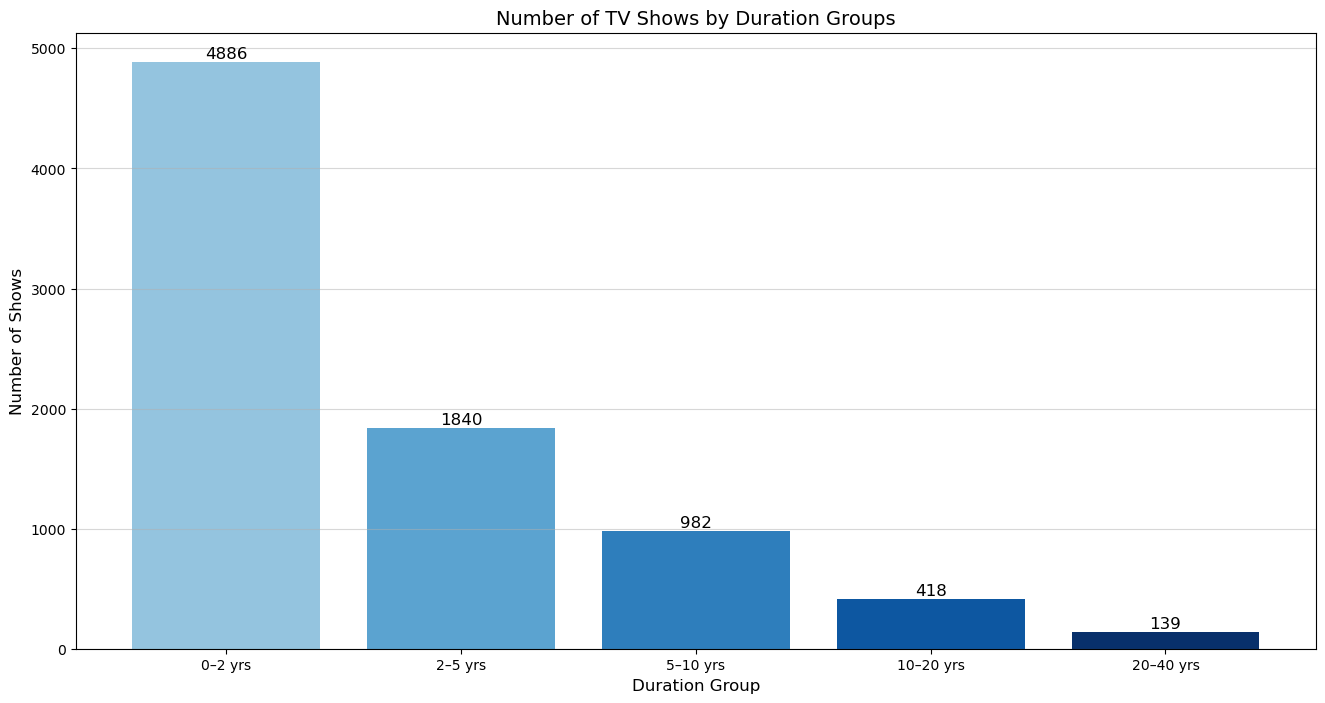

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv("tvshows_cleaned.csv")

# Convert dates to datetime
df['premiered'] = pd.to_datetime(df['premiered'], errors='coerce')
df['ended'] = pd.to_datetime(df['ended'], errors='coerce')

# Compute duration in years (rounded)
df['duration_years'] = ((df['ended'] - df['premiered']).dt.days / 365).round(1)

# Replace negative or missing durations with NaN
df.loc[df['duration_years'] < 0, 'duration_years'] = pd.NA



# --- Visualization 2: Average duration per Type ---
avg_duration_type = df.groupby('type')['duration_years'].mean().sort_values(ascending=False)
plt.figure(figsize=(14,8))
bars = plt.bar(avg_duration_type.index, avg_duration_type.values, color='red', edgecolor='black')
plt.title("Average Duration per TV Show Type")
plt.ylabel("Average Duration (Years)")
plt.xlabel("Show Type")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=11)
plt.show()

bins = [0, 2, 5, 10, 20, 40]
labels = ["0–2 yrs", "2–5 yrs", "5–10 yrs", "10–20 yrs", "20–40 yrs"]
df['duration_group'] = pd.cut(df['duration_years'], bins=bins, labels=labels)

count_per_group = df['duration_group'].value_counts().reindex(labels)

colors = plt.cm.Blues(np.linspace(0.4, 1, len(count_per_group)))

plt.figure(figsize=(16,8))
bars = plt.bar(count_per_group.index, count_per_group.values, color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 29, round(yval,1), ha='center', fontsize=12)

plt.title("Number of TV Shows by Duration Groups", fontsize=14)
plt.xlabel("Duration Group", fontsize=12)
plt.ylabel("Number of Shows", fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()



In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [40]:
df = pd.read_csv("tvshows_cleaned.csv")

df['premiered'] = pd.to_datetime(df['premiered'], errors='coerce')
df['premiered_year'] = df['premiered'].dt.year

features = ['runtime', 'type', 'language', 'genres', 'premiered_year']
df = df[features + ['status']].dropna()

X = df[['runtime', 'premiered_year']].copy()

categorical_cols = ['type', 'language', 'genres']
X_cat = encoder.fit_transform(df[categorical_cols])
X_cat_df = pd.DataFrame(X_cat, columns=encoder.get_feature_names_out(categorical_cols))

X = pd.concat([X.reset_index(drop=True), X_cat_df.reset_index(drop=True)], axis=1)

y = df['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.873900293255132

Classification Report:
                   precision    recall  f1-score   support

           Ended       0.91      0.96      0.93      1806
         Running       0.43      0.26      0.33       202
To Be Determined       0.00      0.00      0.00        38

        accuracy                           0.87      2046
       macro avg       0.45      0.41      0.42      2046
    weighted avg       0.84      0.87      0.85      2046

